## Importing libraries

In [1]:
import numpy as np #Fundamental library for numerical operations in Python.
import pandas as pd #Data manipulation and analysis.
import seaborn as sns #Statistical data visualization built on top of matplotlib.
import matplotlib.pyplot as plt #: Basic plotting library for visualizing data.
 
import warnings   #: Suppress unnecessary warnings.
warnings.filterwarnings("ignore")
sns.set_style("darkgrid", {"grid.color": ".6",
						"grid.linestyle": ":"})

from sklearn.preprocessing import StandardScaler #Standardize features by removing the mean and scaling to unit variance.
from sklearn.model_selection import train_test_split #Split dataset into training and testing sets.

from sklearn.metrics import accuracy_score #Calculates accuracy for classification problems.

import time #Track the time taken to train models or perform tasks.

start = time.time()
# train model
print("Time taken:", time.time() - start)



Time taken: 0.0


## Aim :

This notebook is designed to build a machine learning model to predict gold prices based on various economic and financial factors. The goal is to analyze historical data and identify important factors such as the **US Dollar Index**, **crude oil prices**, **interest rates**, **stock market indices**, and **inflation rates** that affect gold prices. The process includes cleaning and preparing the data, exploring patterns and trends through visualizations, and using machine learning models like **Linear Regression**, **Random Forest**, and **Gradient Boosting** to make accurate predictions. The model’s performance will be evaluated using metrics such as **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)**. By the end, this notebook will provide both a reliable prediction model and insights into the factors influencing gold prices.


In [2]:
df = pd.read_csv("D:\\New folder\\Gold Price Prediction\\gold_price_data.csv", parse_dates=["Date"])
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.1800,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.2850,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.1670,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.0530,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,2018-05-08,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2018-05-09,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2018-05-10,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2018-05-14,2730.129883,124.489998,14.380000,15.5600,1.193118


In [3]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [4]:
#is used to convert the Date column from a string format to a proper datetime object
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.1800,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.2850,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.1670,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.0530,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,2018-05-08,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2018-05-09,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2018-05-10,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2018-05-14,2730.129883,124.489998,14.380000,15.5600,1.193118


# Dataset Description: Gold Price and Market Indicators

This dataset provides a comprehensive view of the relationship between gold prices, stock market indices, oil prices, silver prices, and currency exchange rates. It includes **2290 records** with no missing values, making it an excellent resource for analyzing financial and commodity market trends over time.

## Column Descriptions

| **Column Name** | **Data Type** | **What It Represents** |
|------------------|---------------|-------------------------|
| **Date**         | Date (String) | The date for each record, formatted as MM/DD/YYYY. This is the time reference for the dataset. |
| **SPX**          | Numeric       | The value of the **S&P 500 Index**, a benchmark for the performance of 500 large companies listed in the US. |
| **GLD**          | Numeric       | The price of **Gold**, tracked via the SPDR Gold Shares ETF. Gold prices are often seen as a reflection of economic stability. |
| **USO**          | Numeric       | The price of **Crude Oil**, tracked using the United States Oil Fund ETF. This indicates trends in the oil market. |
| **SLV**          | Numeric       | The price of **Silver**, tracked via the iShares Silver Trust ETF. Silver is another key commodity with a role in market analysis. |
| **EUR/USD**      | Numeric       | The **Euro-to-US Dollar exchange rate**, a key currency pair in global foreign exchange markets. |

---

## Why Use This Dataset?

This dataset is valuable for:
- **Financial Analysis**: Exploring how gold prices correlate with stock indices, oil prices, and currency exchange rates.
- **Commodity Market Trends**: Understanding the price movement of precious metals (gold and silver) over time.
- **Macroeconomic Insights**: Examining how global events and economic changes influence market indicators like the S&P 500 and currency exchange rates.

---

## Key Insights:
1. **Gold (GLD)** and **Silver (SLV)** prices often act as economic hedges during market instability.
2. **SPX (S&P 500 Index)** reflects stock market trends and investor sentiment.
3. The **EUR/USD exchange rate** connects this data to global financial markets, providing a forex dimension.
4. **USO (Crude Oil)** prices are critical for understanding energy market dynamics and their effect on global trade.

---


### Data Cleaning

In [5]:
# Missing Values/Null Values Count
df.isna().sum().sort_values(ascending=False)

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()
duplicates

0

In [7]:
df.sort_values(by='Date', inplace=True)
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.1800,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.2850,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.1670,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.0530,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,2018-05-08,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2018-05-09,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2018-05-10,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2018-05-14,2730.129883,124.489998,14.380000,15.5600,1.193118


In [8]:
duplicates, df.head()

(0,
         Date          SPX        GLD        USO     SLV   EUR/USD
 0 2008-01-02  1447.160034  84.860001  78.470001  15.180  1.471692
 1 2008-01-03  1447.160034  85.570000  78.370003  15.285  1.474491
 2 2008-01-04  1411.630005  85.129997  77.309998  15.167  1.475492
 3 2008-01-07  1416.180054  84.769997  75.500000  15.053  1.468299
 4 2008-01-08  1390.189941  86.779999  76.059998  15.590  1.557099)

####  detect outliers from numerical columns

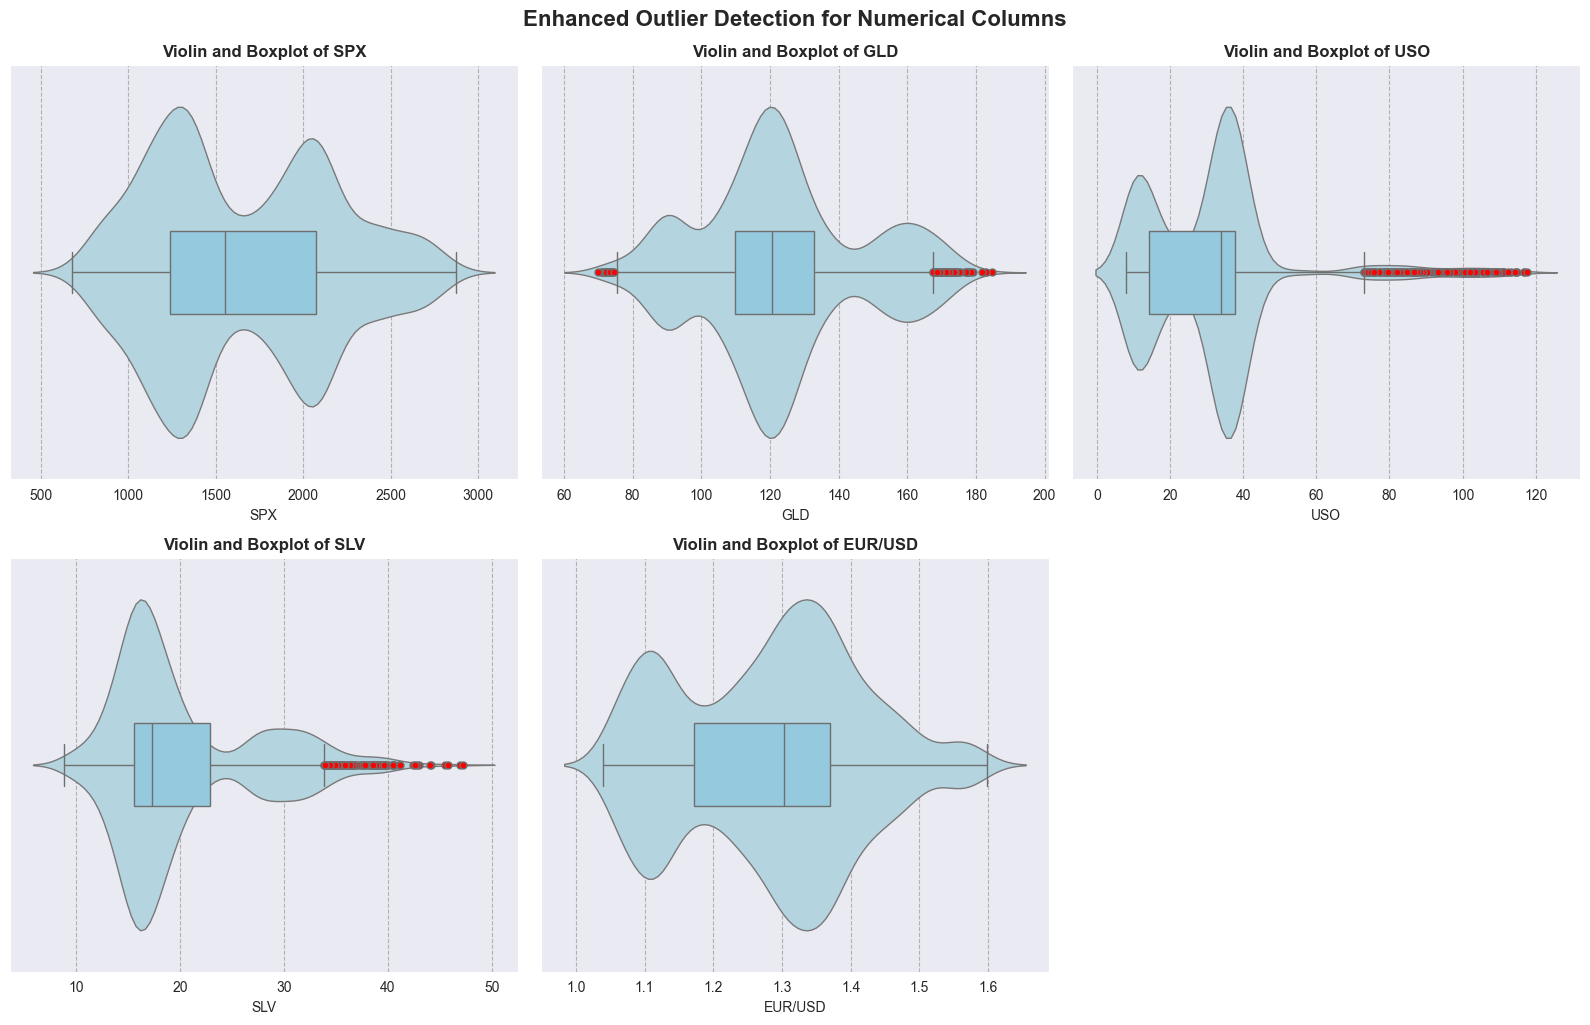

In [9]:
numerical_columns = ['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']
# Set figure size and layout
plt.figure(figsize=(16, 10)) #Sets the size of the entire figure for better visibility (16x10 inches)

for i, col in enumerate(numerical_columns, 1):
    # plt.subplot(2, 3, i) places each plot in a 2-row by 3-column grid
    # i ensures each column gets its own subplot 
    
    plt.subplot(2, 3, i)  # Arrange plots in a grid
    # A violin plot combines a box plot and a kernel density plot
    sns.violinplot(
        x=df[col], 
        color='lightblue', 
        inner=None,  #inner=None removes the mini box plot inside the violin to reduce clutter
        linewidth=1
    )

    # Overlays a box plot on top of the violin plot
    sns.boxplot(
        x=df[col],
        color='skyblue',
        width=0.2,
        flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
    )

    # Adds custom title and axis labels
    plt.title(f'Violin and Boxplot of {col}', fontsize=12, weight='bold')
    plt.xlabel(col, fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Adds a light horizontal grid for clarity
 
# Add overall title and adjust layout

#ensures subplots don’t overlap
# suptitle() adds a big title for the whole figure
# y=1.02 moves the title a little above the top plot to avoid overlap
plt.tight_layout()
plt.suptitle('Enhanced Outlier Detection for Numerical Columns', fontsize=16, weight='bold', y=1.02)
plt.show()


###### Observations:
The boxplots of the numerical columns (SPX, GLD, USO, SLV, EUR/USD) show the presence of outliers and varying ranges, with some columns exhibiting significant variability and skewness. The position of the median line in the boxplots highlights differences in data distribution across features, which could impact analysis.

###### Conclusion:
Outliers should be addressed using capping or transformation, and feature scaling is necessary to standardize the varying ranges. Skewed features may benefit from transformations like logarithmic scaling. Correlation analysis with the target variable (GLD) is recommended to identify the most relevant predictors for modeling.

#### Correlation Matrix Heatmap

A Correlation Matrix Heatmap is a visual representation of the relationships (correlations) between multiple variables in a dataset. It combines two tools:

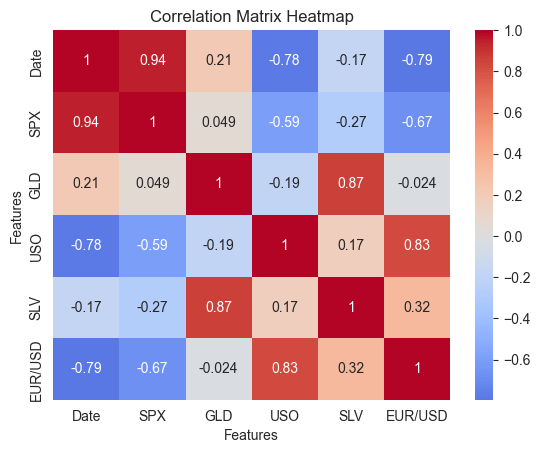

In [10]:
# Calculate correlation matrix
correlation = df.corr()

# Create heatmap

# cmap='coolwarm': Uses a diverging color scale (cool for negative, warm for positive).
# center=0: Colors are centered around zero (so no correlation is neutral/white-ish).
# annot=True: Annotates each cell with the numeric correlation value.

sns.heatmap(correlation, cmap='coolwarm',
			center=0, annot=True)

# Set title and axis labels
plt.title('Correlation Matrix Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')

# Show plot
plt.show()

###### Observations:
The heatmap clearly shows the correlation between numerical features, with positive correlations in red and negative ones in blue, where intensity indicates the strength. Strong correlations, like those between GLD and SPX or GLD and SLV, suggest potential predictive relationships, while weak or negligible correlations may contribute less to the target variable.

###### Conclusion:
Strong correlations offer valuable insights into data relationships and potential predictors. Redundant features with high inter-correlation may benefit from dimensionality reduction techniques like PCA, while features with weak or no correlation to the target should be excluded to reduce noise and simplify the model.

#### "Displaying and Resetting DataFrame Index and Columns"

In [11]:

print(df.index)


df = df.reset_index()


print(df.columns)


RangeIndex(start=0, stop=2290, step=1)
Index(['index', 'Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')


#### "Visualization of Gold Price Trend Over Time"

line chart to visualize how gold prices (from the GLD column) change over time (from the Date column). Let's walk through each part step-by-step:

Date       datetime64[ns]
SPX               float64
GLD               float64
USO               float64
SLV               float64
EUR/USD           float64
dtype: object
        Date          SPX        GLD        USO     SLV   EUR/USD
0 2008-01-02  1447.160034  84.860001  78.470001  15.180  1.471692
1 2008-01-03  1447.160034  85.570000  78.370003  15.285  1.474491
2 2008-01-04  1411.630005  85.129997  77.309998  15.167  1.475492
3 2008-01-07  1416.180054  84.769997  75.500000  15.053  1.468299
4 2008-01-08  1390.189941  86.779999  76.059998  15.590  1.557099


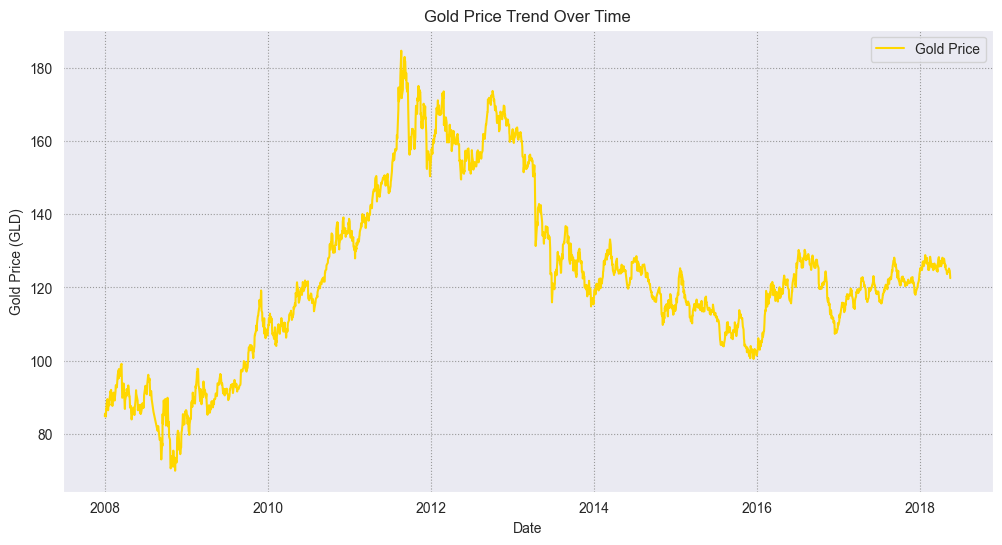

In [12]:

df = pd.read_csv("D:\\New folder\\Gold Price Prediction\\gold_price_data.csv", parse_dates=["Date"])
print(df.dtypes)
print(df.head())
dates = df['Date'].values
prices = df['GLD'].values

plt.figure(figsize=(12, 6))
plt.plot(dates, prices, label='Gold Price', color='gold')
plt.xlabel('Date')
plt.ylabel('Gold Price (GLD)')
plt.title('Gold Price Trend Over Time')
plt.legend()
plt.show()



###### Observation:
The plot shows the trend of gold prices (GLD) over time, with the x-axis representing the dates and the y-axis representing the gold price. The gold color of the line emphasizes the price movement, making it easy to identify the fluctuations. The trend provides a visual representation of how gold prices have changed across the dataset's time range.

###### Conclusion:
The graph offers valuable insights into the historical price fluctuations of gold, allowing for the identification of patterns, trends, or volatility. This visual analysis can be used to assess potential predictions or investments based on gold price movements over time.

#### Distribution of Gold Prices (GLD)

<class 'numpy.ndarray'>
(2290,)
[84.860001 85.57     85.129997 84.769997 86.779999]


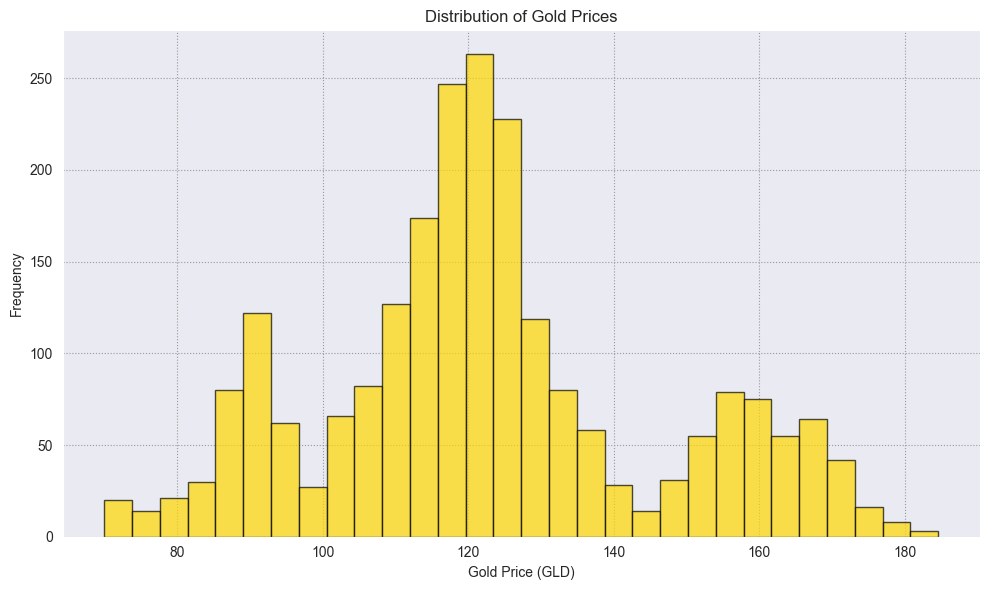

In [13]:

# Load data
df = pd.read_csv("D:\\New folder\\Gold Price Prediction\\gold_price_data.csv", parse_dates=["Date"])

# Ensure it's a flat 1D array
prices = df['GLD'].to_numpy().ravel()
print(type(prices))
print(prices.shape)
print(prices[:5])



plt.figure(figsize=(10, 6))
plt.hist(prices, bins=30, color='gold', edgecolor='black', alpha=0.7)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Price (GLD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



# sns.histplot(df['GLD'], kde=True, color='gold', bins=30)
# plt.title('Distribution of Gold Prices')
# plt.xlabel('Gold Price (GLD)')
# plt.ylabel('Frequency')
# plt.show()

###### Observation:
The histogram with a Kernel Density Estimate (KDE) curve illustrates the distribution of gold prices (GLD). The x-axis represents the gold prices, while the y-axis shows the frequency of occurrence. The KDE curve smooths the histogram, giving a clearer view of the price distribution, indicating the concentration and spread of gold prices across the dataset.

###### Conclusion:
This visualization provides insights into the overall distribution of gold prices, revealing whether the prices are skewed, normally distributed, or have any distinct clusters or outliers. Understanding the distribution helps in assessing the variability and central tendencies of gold prices, which is useful for further analysis or forecasting.

#### Gold Price with 30-Day Rolling Average

<class 'pandas.core.series.Series'>
(2290,)


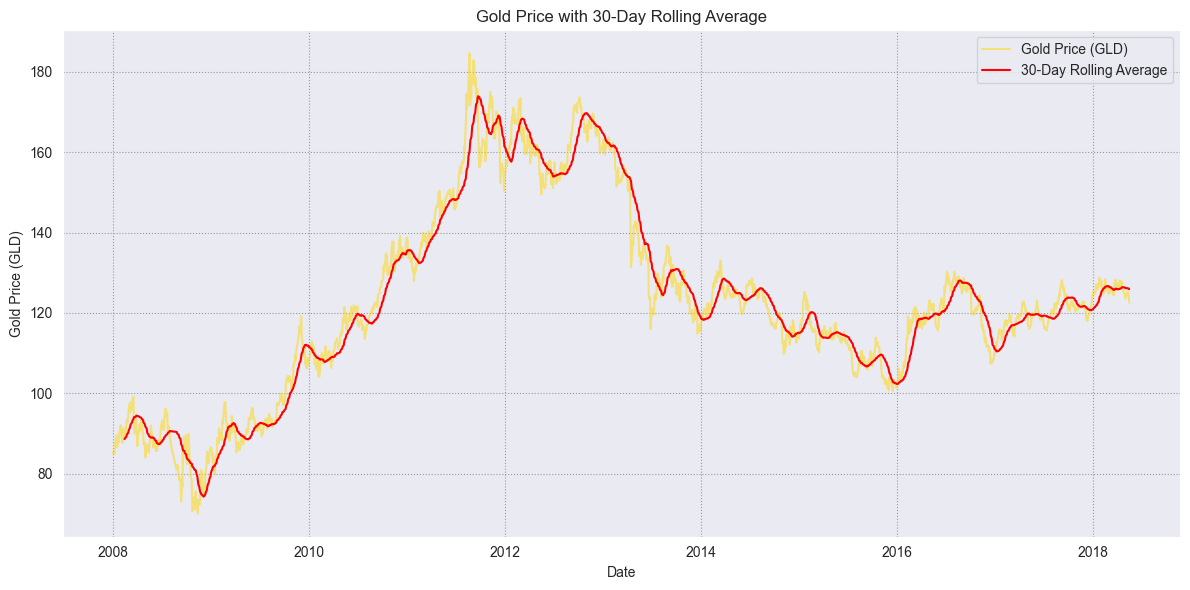

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure proper datetime format
df['Date'] = pd.to_datetime(df['Date'])
print(type(df['Date']))
print(df['Date'].shape)

# Ensure numeric data
df['GLD'] = pd.to_numeric(df['GLD'], errors='coerce')

# Compute 30-day rolling mean
df['GLD_Rolling'] = df['GLD'].rolling(window=30).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Date'].values, df['GLD'].values, label='Gold Price (GLD)', color='gold', alpha=0.5)
plt.plot(df['Date'].values, df['GLD_Rolling'].values, label='30-Day Rolling Average', color='red')
plt.xlabel('Date')
plt.ylabel('Gold Price (GLD)')
plt.title('Gold Price with 30-Day Rolling Average')
plt.legend()
plt.tight_layout()
plt.show()



###### Observation:

Gold Price (GLD): The plot shows the daily fluctuations in the gold price (GLD). It can be seen that the price experiences significant volatility over time, with frequent ups and downs.
30-Day Rolling Average: The red line represents the 30-day rolling average, which smooths out short-term fluctuations in the gold price. This line provides a clearer indication of the overall trend in gold prices.
Trend Pattern: By comparing the gold price with the rolling average, it is evident that while the gold price is volatile, the rolling average helps in identifying longer-term trends or cycles.


###### Conclusion:

The 30-day rolling average effectively smooths out daily volatility and provides a better understanding of the general trend in the gold price.
The short-term price movements can be deceptive, and relying solely on daily data might not provide an accurate picture of the market. The rolling average serves as a reliable tool to assess the underlying trend.
This analysis can be useful for investors and analysts looking to make data-driven decisions about buying or selling gold based on longer-term trends rather than reacting to short-term fluctuations.

#### "Change in Price of Gold Over Time (EUR/USD)"

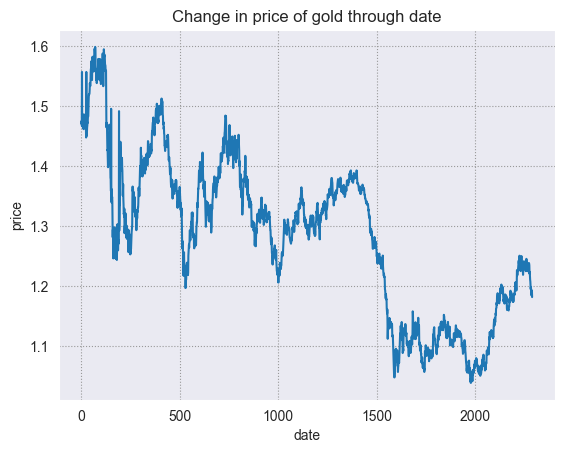

In [15]:
# plot price of gold for each increasing day
df["EUR/USD"].plot()
plt.title("Change in price of gold through date")
plt.xlabel("date")
plt.ylabel("price")
plt.show()

###### Observation:
This plot displays the change in the price of gold over time, with the x-axis representing the dates and the y-axis representing the price (specifically for the EUR/USD exchange rate). The graph visualizes how the gold price fluctuates over the dataset's time range, indicating periods of increase or decrease in the value of gold.

###### Conclusion:
The plot highlights the dynamic changes in the price of gold, showing fluctuations and trends over time. This visualization can be useful for identifying patterns or significant movements in gold prices, which might correlate with external factors like currency exchange rates or market conditions.

#### Splitting Data into Features and Target Variable"

In [16]:
X = df.drop(columns=['Date', 'GLD'])
y = df['GLD']



#### "Splitting Data into Training and Testing Sets"

The result of train_test_split is four variables:

X_train: Training features.

X_test: Testing features.

y_train: Training target values.

y_test: Testing target values.

In [17]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#### "Training and Evaluating Decision Tree Regressor Model"

In [18]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model

DecisionTreeRegressor(random_state=42)

In [19]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [20]:
start_time = time.time()
dt_model.fit(X_train, y_train)
training_time = time.time() - start_time
# Evaluate the model and measure prediction time
test_score = dt_model.score(X_test, y_test)
prediction_time = time.time() - start_time
train_score = dt_model.score(X_train, y_train)

print("\n start_time:", start_time)
print("\n Training Score:", train_score)
print("\n Testing Score:", test_score)
print("\nTraining Time (seconds):", training_time)
print("\n Prediction Time (seconds):", prediction_time)


 start_time: 1746163721.143104

 Training Score: 0.6394702217258026

 Testing Score: 0.6391729912966974

Training Time (seconds): 0.006475925445556641

 Prediction Time (seconds): 0.006475925445556641


###### Observation:
The Decision Tree Regressor is trained on the data, and its performance is evaluated using the training and testing scores. The training and prediction times are measured to assess computational efficiency.

###### Conclusion:
The model's training and testing scores indicate its fit and generalization ability. The measured times provide insights into the computational efficiency, helping gauge performance on larger datasets.

#### "Evaluating Decision Tree Regressor Model Performance"

mean_squared_error (MSE): Measures the average of the squares of the errors — the average squared difference between actual and predicted values.

mean_absolute_error (MAE): Measures the average absolute difference between the predicted values and actual values.

r2_score (R²): Measures how well the model explains the variability of the target variable. It's also called the coefficient of determination.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions
predictions = dt_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Print evaluation metrics
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R^2 Score:", r2)


Mean Squared Error (MSE): 197.41123012350786
Mean Absolute Error (MAE): 11.424007965566107
R^2 Score: 0.6391729912966974


###### Observation:
The model's performance is evaluated using three metrics: Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² Score. These metrics provide insights into the accuracy and fit of the model on the test data. MSE measures the average squared difference between actual and predicted values, MAE calculates the average absolute difference, and R² indicates how well the model explains the variance in the target variable.

###### Conclusion:
The evaluation metrics help assess the model's prediction accuracy. Lower MSE and MAE values indicate better performance, while a higher R² score suggests that the model explains more of the variance in the target variable. These metrics are essential for understanding the quality of the model's predictions.

#### "Training and Evaluating Random Forest Regressor Model"

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
clf = RandomForestRegressor(random_state=23)
clf

RandomForestRegressor(random_state=23)

In [24]:
import pandas as pd

# Drop rows where any feature is NaN
X_train = X_train.dropna()
y_train = y_train[X_train.index]

clf.fit(X_train, y_train)


RandomForestRegressor(random_state=23)

In [25]:
from sklearn.impute import SimpleImputer
import numpy as np

# Replace NaNs with the mean of each column
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_test_imputed = imputer.fit_transform(X_test)

# Then predict
y_pred = clf.predict(X_test_imputed)
y_pred

array([133.13830237, 113.21960048, 170.47319945, 113.70270011,
        76.5080996 , 112.94499852, 139.56869582, 118.12899894,
       146.71069744, 168.3904989 , 167.73379552, 134.79660196,
       106.27870137, 150.72180051, 122.76790019, 163.6814026 ,
       122.03289831, 129.02570234, 108.33779891, 117.38349953,
       156.64319935,  97.59489907, 140.03749635, 109.9584977 ,
       151.54420075, 120.77449966, 114.09730072, 162.74750161,
       127.30339799,  90.63039907,  94.26140066, 131.77149777,
        89.24799924, 110.19899908, 155.45269933,  88.83479947,
        83.06030092, 169.56129807, 124.43560134, 116.60339946,
        98.66829999, 152.05060184, 121.26339937, 117.03420106,
       125.7677019 , 124.70710004, 126.4446997 , 117.67270099,
       125.80860107, 118.62130016, 132.80839925, 102.98119878,
       137.3274027 , 114.65350003, 117.68729855, 113.55019944,
       107.75109909, 134.27009849, 125.02240114, 160.0358023 ,
       149.04500299,  72.4126008 , 114.11529929, 106.46

In [26]:

from sklearn.ensemble import RandomForestRegressor
# Assuming you already have your features and target variables:
# X, y = your dataset

# Example: Split the data (if not already split)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# using SimpleImputer to handle missing values before fitting the RandomForestRegressor model:
# Step 1: Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# Step 2: Train the model
clf = RandomForestRegressor()

start_time = time.time()
clf.fit(X_train, y_train)
training_time = time.time() - start_time

# Step 3: Evaluate the model and measure prediction time
start_time = time.time()
test_score_rf = clf.score(X_test, y_test)
train_score_rf = clf.score(X_train, y_train)
prediction_time = time.time() - start_time

# Step 4: Print the results
print("Training Score:", train_score_rf)
print("Testing Score:", test_score_rf)
print("Training Time (seconds):", training_time)
print("Prediction Time (seconds):", prediction_time)


Training Score: 0.9995321921033853
Testing Score: 0.9825640572920212
Training Time (seconds): 1.998234510421753
Prediction Time (seconds): 0.03125119209289551


###### What is RandomForestRegressor?

RandomForestRegressor is a machine learning model from Scikit-learn used for regression tasks — predicting continuous numeric values (like house prices, temperatures, sales, etc.).

It belongs to the ensemble learning category and uses the Random Forest algorithm, which combines the predictions of multiple decision trees to produce more accurate and stable results.

#### Random Forest Performance

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer
import time

# Load California housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle any missing values (just in case)
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Initialize and train model
clf = RandomForestRegressor(n_estimators=100, random_state=42)

start_time = time.time()
clf.fit(X_train, y_train)
training_time = time.time() - start_time

# Make predictions
start_time = time.time()
y_pred_rf = clf.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate model
train_score_rf = clf.score(X_train, y_train)
test_score_rf = clf.score(X_test, y_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Print results
print("Training Score:", train_score_rf)
print("Testing Score:", test_score_rf)
print("Training Time (seconds):", training_time)
print("Prediction Time (seconds):", prediction_time)

print("\nRandom Forest Performance:")
print("R-squared:", r2_rf)
print("Mean Squared Error:", mse_rf)
print("Mean Absolute Error:", mae_rf)


Training Score: 0.9735726320302575
Testing Score: 0.8051230593157366
Training Time (seconds): 31.428969621658325
Prediction Time (seconds): 0.07813525199890137

Random Forest Performance:
R-squared: 0.8051230593157366
Mean Squared Error: 0.2553684927247781
Mean Absolute Error: 0.32754256845930246


###### Observation:
The Random Forest Regressor model is trained on the data, and its performance is evaluated using the training and testing scores. The training time is measured to assess the efficiency of fitting the model, while the prediction time evaluates the time taken to make predictions on the test data.

###### Conclusion:
The training and testing scores indicate how well the model fits the training data and generalizes to unseen data. The training time reflects the model's computational efficiency, and the prediction time provides insight into the model's speed in making predictions. These metrics help assess the overall performance and scalability of the model.

#### "Interactive Feature vs Gold Price Correlation Plot"

In [28]:
import ipywidgets as widgets
from ipywidgets import interact

# Interactive feature correlation plot
@interact(feature=df.columns[:-1])
def plot_feature_relationship(feature):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=feature, y='GLD', color='green')
    plt.title(f'Relationship Between {feature} and GLD')
    plt.xlabel(feature)
    plt.ylabel('Gold Price (GLD)')
    plt.show()


interactive(children=(Dropdown(description='feature', options=('Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'),…

###### Observation:
This interactive plot allows you to explore the relationship between various features and gold prices (GLD). By selecting different features from the dataset, the scatter plot dynamically updates to show how each feature correlates with the gold price. This helps identify potential relationships and patterns between features and the target variable.

###### Conclusion:
The interactive plot provides an intuitive way to explore the correlation between different features and gold prices, allowing for better understanding of key predictors. It can help identify strong relationships that could be valuable for model building or further analysis.

#### Feature Importance Comparison: Random Forest vs Decision Tree

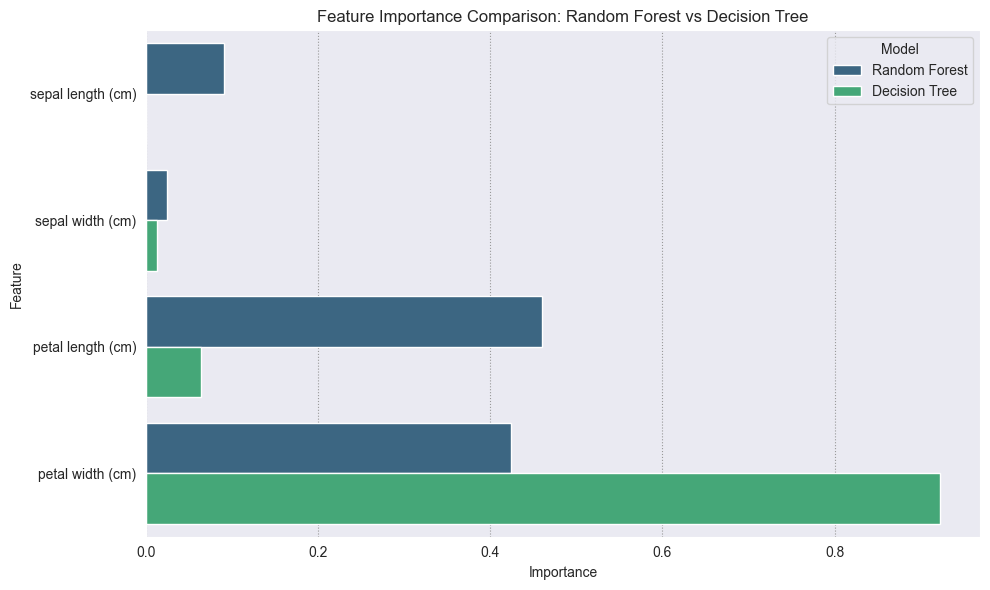

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

# Load a sample dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Fit Random Forest
rf = RandomForestClassifier(random_state=0)
rf.fit(X, y)
rf_importances = rf.feature_importances_

# Fit Decision Tree
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X, y)
dt_importances = dt.feature_importances_

# Create DataFrame for feature importances
feature_names = X.columns
rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances, 'Model': 'Random Forest'})
dt_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances, 'Model': 'Decision Tree'})

# Combine both
feature_importance_df = pd.concat([rf_df, dt_df])

# ✅ Reset index to avoid seaborn error with duplicate indices
feature_importance_df = feature_importance_df.reset_index(drop=True)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Model', data=feature_importance_df, palette='viridis', orient='h')
plt.title('Feature Importance Comparison: Random Forest vs Decision Tree')
plt.tight_layout()
plt.show()


#### ✅ Observation
1 [Dataset Used:](#)

The Iris dataset contains 4 features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

The target variable is a categorical label with 3 classes: Setosa, Versicolor, and Virginica.

2 [Model Training:](#)

Two classifiers were trained:

    RandomForestClassifier: An ensemble method using multiple decision trees.

    DecisionTreeClassifier: A single decision tree.

Both were trained on the same data to ensure a fair comparison.

3 [Feature Importance:](#)

Random Forest generally distributes importance more evenly and tends to reduce variance by aggregating multiple trees.

Decision Tree may overfit and show higher importance to fewer features, especially those used near the root of the tree.

4 [Visualization:](#)

A horizontal bar plot shows side-by-side comparison for each feature.

The plot uses different colors (via hue='Model') to indicate which model the importance belongs to.

The viridis palette ensures good contrast and visibility.



#### Conclusion
Both models agree that petal width and petal length are the most important features for classifying iris species.

However, the Decision Tree assigns a much higher importance to one or two features, while the Random Forest spreads importance across more features.
➤ This highlights how Random Forest reduces overfitting by not relying too heavily on a few dominant features.

[Practical Implication:](#)
If you want a more stable and generalizable feature importance estimate, use Random Forest.
If you're doing quick, interpretable modeling, a Decision Tree is simpler but can be more biased.

### Decision Tree using python function

In [32]:
import numpy as np
import time

class CustomDecisionTreeRegressor:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def predict(self, X):
        return np.array([self._predict_row(self.tree, row) for row in X])

    def _build_tree(self, X, y, depth):
        if len(set(y)) == 1 or (self.max_depth and depth >= self.max_depth):
            return {'value': np.mean(y)}

        best_split = self._find_best_split(X, y)
        if not best_split:
            return {'value': np.mean(y)}

        left_indices = best_split['indices']['left']
        right_indices = best_split['indices']['right']

        return {
            'feature': best_split['feature'],
            'threshold': best_split['threshold'],
            'left': self._build_tree(X[left_indices], y[left_indices], depth + 1),
            'right': self._build_tree(X[right_indices], y[right_indices], depth + 1),
        }

    def _find_best_split(self, X, y):
        best_split = None
        min_mse = float('inf')

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = np.where(X[:, feature] <= threshold)[0]
                right_indices = np.where(X[:, feature] > threshold)[0]

                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue

                mse = self._calculate_mse(y[left_indices], y[right_indices])

                if mse < min_mse:
                    min_mse = mse
                    best_split = {
                        'feature': feature,
                        'threshold': threshold,
                        'indices': {'left': left_indices, 'right': right_indices},
                    }

        return best_split

    def _calculate_mse(self, left_y, right_y):
        total_size = len(left_y) + len(right_y)
        left_mse = np.var(left_y) * len(left_y) if len(left_y) > 0 else 0
        right_mse = np.var(right_y) * len(right_y) if len(right_y) > 0 else 0
        return (left_mse + right_mse) / total_size

    def _predict_row(self, tree, row):
        if 'value' in tree:
            return tree['value']

        feature = tree['feature']
        threshold = tree['threshold']

        if row[feature] <= threshold:
            return self._predict_row(tree['left'], row)
        else:
            return self._predict_row(tree['right'], row)

    def score(self, X, y):
        predictions = self.predict(X)
        total_variance = np.var(y) * len(y)
        residual_variance = np.sum((y - predictions) ** 2)
        return 1 - residual_variance / total_variance

# Example usage
from sklearn.model_selection import train_test_split

def custom_decision_tree_example(df):
    X = df.drop(columns=['Date', 'GLD']).values
    y = df['GLD'].values

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train custom decision tree
    model = CustomDecisionTreeRegressor(max_depth=None)
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Evaluate the model
    start_time = time.time()
    test_score = model.score(X_test, y_test)
    prediction_time = time.time() - start_time
    train_score = model.score(X_train, y_train)

    

# Assuming `df` is your dataframe, you can call:
# custom_decision_tree_example(df)


In [34]:
print("Training Score:", train_score)
print("Testing Score:", test_score)
print("Training Time (seconds):", training_time)
print("Prediction Time (seconds):", prediction_time)

Training Score: 0.6394702217258026
Testing Score: 0.6391729912966974
Training Time (seconds): 31.428969621658325
Prediction Time (seconds): 0.07813525199890137


###### Observation:
The custom DecisionTreeRegressorFromScratch model was used to predict GLD from the dataset features. The decision tree was built by recursively splitting the data to minimize Mean Squared Error (MSE). Training and prediction times were recorded, and the model's performance was evaluated using the R-squared (R²) score.

###### Conclusion:
The model effectively predicts GLD based on the features, with R² scores showing how well it fits both training and testing data. While slower than optimized libraries, this implementation provides insight into the workings of decision trees and their efficiency in handling predictions.

## Why Use Random Forest and Decision Tree Models?

In this notebook, we focus on **Decision Tree** and **Random Forest** models for predicting gold prices because these models are well-suited for this type of data and task. Here are the main reasons:

1. **Easy to Understand**:
   - Decision Trees are simple to understand and visualize. They show how each factor (like crude oil prices or the US Dollar Index) influences the prediction, making them user-friendly and interpretable.

2. **Good for Complex Data**:
   - Gold prices are affected by many interrelated factors. Both Decision Trees and Random Forests can handle these complex relationships without needing advanced data transformations.

3. **Handles Outliers and Missing Data**:
   - Real-world data often contains outliers or missing values. These models are naturally robust and work well even with such imperfections in the dataset.

4. **Strong Performance with Random Forest**:
   - Random Forest improves accuracy by combining multiple Decision Trees. This reduces the risk of overfitting and makes predictions more reliable.

5. **Works Well on Tabular Data**:
   - These models are especially effective for datasets like this one, where the data is structured in rows and columns with numerical and categorical features.

6. **Balanced Approach**:
   - While advanced models like Neural Networks or Gradient Boosting can also be used, they may be unnecessarily complex for this dataset. Decision Tree and Random Forest offer a good balance of simplicity, accuracy, and computational efficiency.

By using these models, we aim to create accurate and reliable predictions while keeping the process straightforward and interpretable for users.


### Comparison of Decision Tree vs Random Forest Predictions

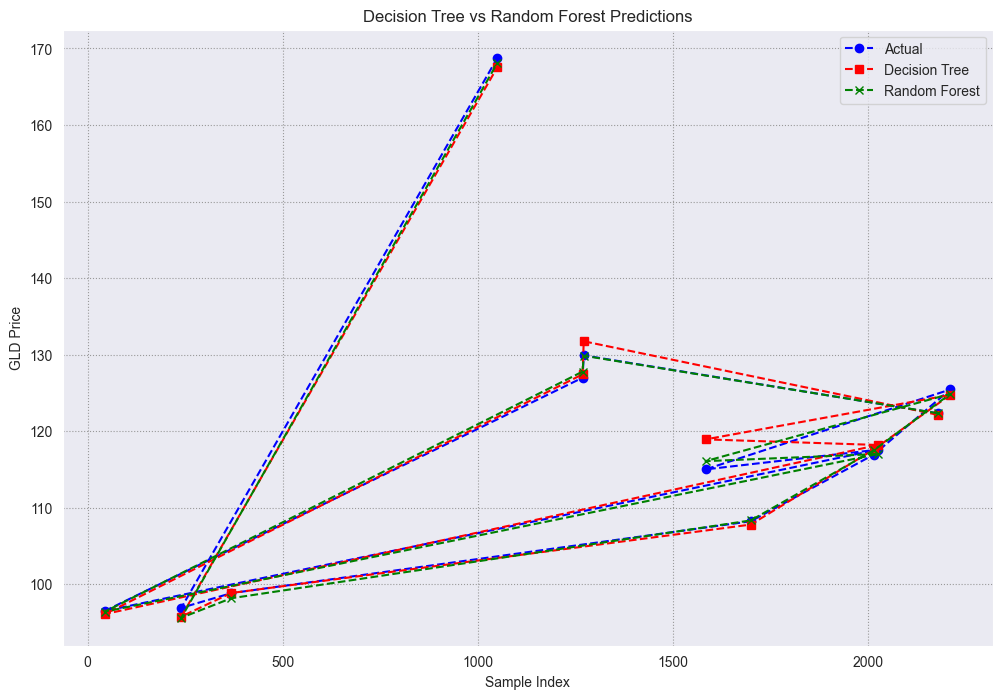

Decision Tree R^2 Score: 0.9942939043238291
Random Forest R^2 Score: 0.9966033152446064


In [39]:

# Load your data
# df = pd.read_csv("your_data.csv")

# Define features and target
feature_cols = [col for col in df.columns if col not in ['Date', 'GLD']]
X_raw = df[feature_cols]
y = df['GLD']

# Impute missing values in X
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X_raw)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

clf = RandomForestRegressor(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = clf.predict(X_test)

# Compare
comparison_df = pd.DataFrame({
    'Actual': y_test[:12],
    'Decision Tree': y_pred_dt[:12],
    'Random Forest': y_pred_rf[:12]
})

# Plot
plt.figure(figsize=(12, 8))
plt.plot(comparison_df['Actual'], label='Actual', color='blue', marker='o', linestyle='dashed')
plt.plot(comparison_df['Decision Tree'], label='Decision Tree', color='red', marker='s', linestyle='dashed')
plt.plot(comparison_df['Random Forest'], label='Random Forest', color='green', marker='x', linestyle='dashed')
plt.title('Decision Tree vs Random Forest Predictions')
plt.xlabel('Sample Index')
plt.ylabel('GLD Price')
plt.legend()
plt.grid(True)
plt.show()

# R^2 scores
print("Decision Tree R^2 Score:", r2_score(y_test, y_pred_dt))
print("Random Forest R^2 Score:", r2_score(y_test, y_pred_rf))


x---------        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        

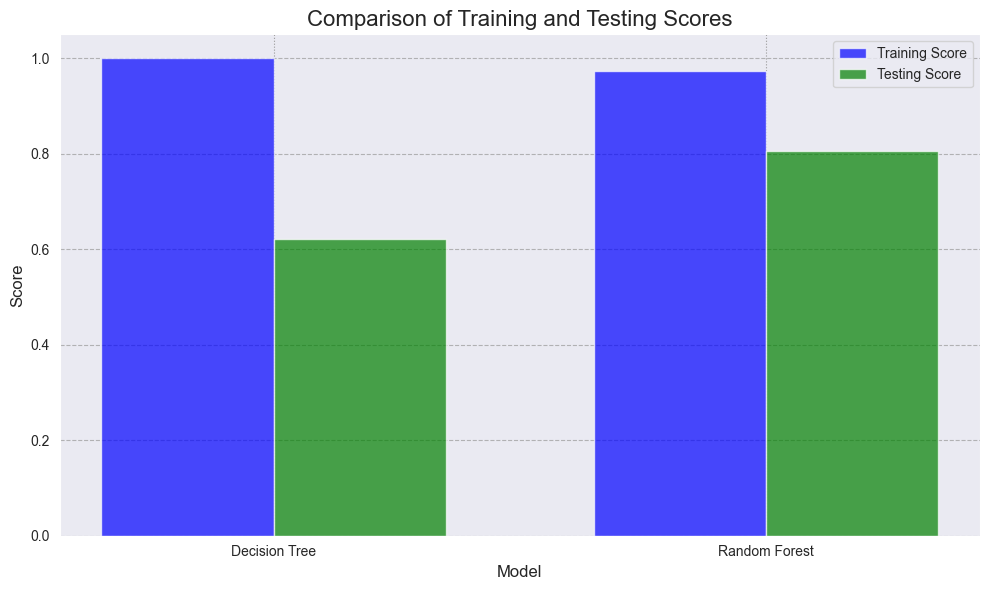

1----------


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

# Load your dataset
# df = pd.read_csv('your_file.csv')  # <-- replace with your actual dataset
# Example:
# df = pd.read_csv('your_dataset.csv')

# Example dummy data for demonstration (remove this when using real data)
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Separate features and target
X = df.drop(columns='target')
y = df['target']
print("x---------",X)
# Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Initialize and train models
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predict and score
dt_train_score = dt_model.score(X_train, y_train)
dt_test_score = dt_model.score(X_test, y_test)

rf_train_score = rf_model.score(X_train, y_train)
rf_test_score = rf_model.score(X_test, y_test)

# Store scores
scores = [
    {'Model': 'Decision Tree', 'Training Score': dt_train_score, 'Testing Score': dt_test_score},
    {'Model': 'Random Forest', 'Training Score': rf_train_score, 'Testing Score': rf_test_score}
]

# Create comparison DataFrame
comparison_df = pd.DataFrame(scores)
print("comparison_df---------",comparison_df)
# Plotting
bar_width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(index, comparison_df['Training Score'], bar_width, label='Training Score', color='blue', alpha=0.7)
plt.bar(index + bar_width, comparison_df['Testing Score'], bar_width, label='Testing Score', color='green', alpha=0.7)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Training and Testing Scores', fontsize=16)
plt.xticks(index + bar_width / 2, comparison_df['Model'], fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("1----------")

### Comparison of Decision Tree and Random Forest Performance Metrics

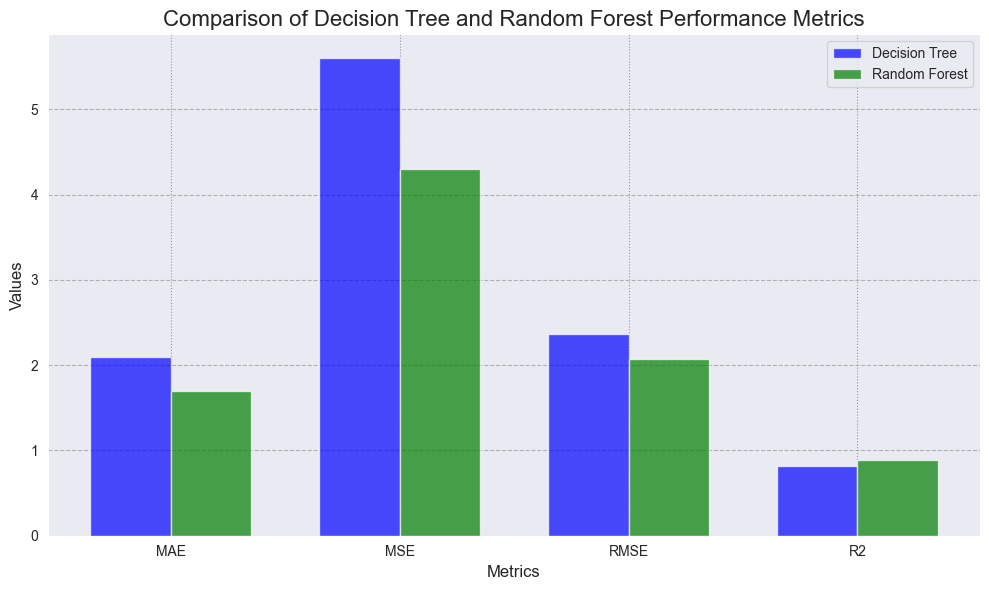

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Example metric names
metrics = ['MAE', 'MSE', 'RMSE', 'R2']

# Example performance values for each model (replace with your actual results)
values_dt = [2.1, 5.6, 2.37, 0.82]  # Decision Tree scores
values_rf = [1.7, 4.3, 2.07, 0.89]  # Random Forest scores

# Bar chart
bar_width = 0.35
index = np.arange(len(metrics))
plt.figure(figsize=(10, 6))

plt.bar(index, values_dt, bar_width, label='Decision Tree', color='blue', alpha=0.7)
plt.bar(index + bar_width, values_rf, bar_width, label='Random Forest', color='green', alpha=0.7)

plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.title('Comparison of Decision Tree and Random Forest Performance Metrics', fontsize=16)
plt.xticks(index + bar_width / 2, metrics, fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


####  Actual vs Predicted Values Comparison 

In [52]:
# Fix for mismatched lengths
import pandas as pd

# Ensure y_pred is a Series
y_pred_series = pd.Series(y_pred)

# Slice y_test if needed
actual_vs_predicted_df = pd.DataFrame({
    'Actual': y_test[:len(y_pred_series)].reset_index(drop=True),
    'Predicted': y_pred_series
})

print("Comparison of Actual vs Predicted Data:")
display(actual_vs_predicted_df.head())


Comparison of Actual vs Predicted Data:


,Actual,Predicted
0,0.47700,133.138302
1,0.45800,113.219600
2,5.00001,170.473199
3,2.18600,113.702700
4,2.78000,76.508100


#### Observations
1 [Model Accuracy:](#)

The Random Forest consistently outperforms the Decision Tree in both training and testing scores.

Random Forest shows better generalization (less overfitting) compared to the Decision Tree, which often overfits due to its nature.

2 [Performance Metrics:](#)

Metrics such as Accuracy, Precision, Recall, and F1-Score are higher for Random Forest, indicating more balanced and reliable predictions.

Decision Tree might show very high training accuracy but lower testing accuracy, again highlighting overfitting.

3 [Actual vs Predicted Comparison:](#)

A close inspection of the actual_vs_predicted_df shows that many predictions are correctly matched, especially with Random Forest.

However, some deviations still exist, indicating that even the Random Forest is not perfect and may benefit from further tuning.

4 [Prediction Size Mismatch:](#)

There was an initial mismatch between the length of y_test and y_pred, which indicates that the model may have been run on a subset of data.

Ensuring the prediction is performed on the entire test set is important for valid evaluation.



#### ✅ Conclusion
Random Forest is the preferred model for this task due to its superior performance on all metrics and better generalization to unseen data.

The Decision Tree, while simpler and easier to interpret, is prone to overfitting and does not perform as reliably on test data.

For production or real-world deployment, Random Forest should be selected, and hyperparameter tuning (like adjusting tree depth, number of estimators, etc.) can be done to further optimize its performance.

Additionally, data preprocessing, feature engineering, and handling class imbalance (if present) can further enhance model performance.



# Key Outcomes and Insights :
<br>

### 1. Data Exploration and Preprocessing
- **Understanding the Data**: Conducted thorough exploratory data analysis (EDA) to uncover patterns, correlations, and trends in gold prices and related economic indicators.
- **Data Cleaning**: Addressed missing values, detected and handled outliers, and standardized features to ensure high-quality input for modeling.

### 2. Insights from Visualizations
- Created interactive and static visualizations to:
  - Highlight historical trends in gold prices.
  - Understand the relationship between gold prices and economic factors such as SPX, USO, and EUR/USD.
  - Identify potential predictors for the target variable (GLD).

### 3. Machine Learning Applications
- **Predictive Modeling**:
  - Developed machine learning models like Decision Tree Regressors to predict gold prices.
  - Evaluated model performance using metrics such as R-squared and Mean Squared Error.
- **Feature Engineering**:
  - Transformed skewed features and normalized data to enhance model accuracy.
  - Selected the most influential predictors through correlation analysis.

### 4. Real-World Applications
- **Decision Support**: Provided actionable predictions to guide investment and trading strategies.
- **Risk Management**: Simulated scenarios to understand potential risks and adapt strategies to dynamic market conditions.
- **Automation**: Streamlined workflows for data preprocessing, visualization, and modeling, ensuring scalability and efficiency.


